# Week 3: Advanced Data Analysis & Visualization in Logistics
**Logistics Data Analyst Internship**  
**Author:** Saurabh Kumar  
**Objective:** Perform comprehensive Exploratory Data Analysis (EDA) on the 1,500 logistics records, evaluate core operational KPIs, generate diagnostic visualizations, compute correlation structures, and segment operational shipments using K-Means clustering.

---

## 1. Dataset Loading & Baseline Logistics KPIs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Visual styling
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Load cleaned analytical dataset
data_path = "../../data/processed/logistics_cleaned.csv"
try:
    df = pd.read_csv(data_path)
except FileNotFoundError:
    df = pd.read_csv("../../simulated_logistics_dataset.csv")

print(f"Analytical dataset loaded: {df.shape[0]} shipments")
df.head()

Analytical dataset loaded: 1500 shipments


,order_id,region,shipping_mode,vehicle_type,warehouse,weather,distance_km,shipment_volume,fuel_price,delivery_time_days,scheduled_days,late_delivery,transport_cost,order_value,profit,cost_is_outlier,distance_scaled,volume_scaled
0,100001,West,Second Class,Mini Truck,WH-B,Clear,141.748163,28.493749,98.459058,2.775334,3.0,0,2251.503544,2031.076646,622.67,1,0.006222,-0.241920
1,100002,East,Same Day,Truck,WH-A,Clear,118.500879,40.272770,105.472271,1.743251,1.0,1,2251.503544,3012.072273,1768.80,1,-0.294569,0.345398
2,100003,Central,Standard,Van,WH-C,Clear,204.640837,18.185547,94.368445,3.368115,5.0,0,2251.503544,2137.516262,596.09,1,0.819973,-0.755902
3,100004,West,Standard,Truck,WH-B,Rain,85.716277,29.051444,99.305041,3.324719,5.0,0,2251.503544,2313.341351,1117.14,1,-0.718760,-0.214113
4,100005,North,First Class,Van,WH-D,Cloudy,160.451514,28.067041,101.268911,1.609597,2.0,0,2659.739766,1958.744356,555.66,1,0.248219,-0.263197


### 1.1 Core Operational KPI Summary

In [2]:
on_time_rate = (df["delivery_time_days"] <= df["scheduled_days"]).mean() * 100
late_delivery_rate = 100 - on_time_rate
avg_delivery_time = df["delivery_time_days"].mean()
avg_transport_cost = df["transport_cost"].mean()
avg_order_value = df["order_value"].mean()
avg_profit = df["profit"].mean()

kpi_df = pd.DataFrame({
    "Logistics KPI": [
        "On-Time Delivery Rate (%)",
        "Late Delivery Rate (%)",
        "Average Delivery Time (Days)",
        "Average Transport Cost ($)",
        "Average Order Value ($)",
        "Average Profit per Order ($)"
    ],
    "Simulated Result": [
        f"{on_time_rate:.2f}%",
        f"{late_delivery_rate:.2f}%",
        f"{avg_delivery_time:.2f} days",
        f"{avg_transport_cost:.2f}",
        f"{avg_order_value:.2f}",
        f"{avg_profit:.2f}"
    ]
})

kpi_df

,Logistics KPI,Simulated Result
0,On-Time Delivery Rate (%),56.00%
1,Late Delivery Rate (%),44.00%
2,Average Delivery Time (Days),3.56 days
3,Average Transport Cost ($),1248.97
4,Average Order Value ($),2332.97
5,Average Profit per Order ($),977.08


## 2. Visualization 1: Delivery Time by Shipping Mode
Evaluates average delivery duration across customer SLA service tiers.

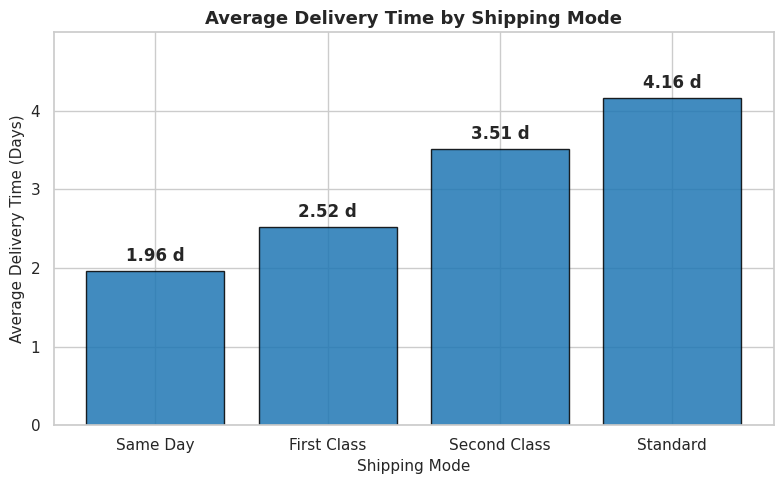

In [3]:
mode_order = ["Same Day", "First Class", "Second Class", "Standard"]
delivery_by_mode = df.groupby("shipping_mode")["delivery_time_days"].mean().reindex(mode_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(delivery_by_mode.index, delivery_by_mode.values, color="#1f77b4", edgecolor="black", alpha=0.85)
plt.title("Average Delivery Time by Shipping Mode", fontsize=13, fontweight="bold")
plt.xlabel("Shipping Mode", fontsize=11)
plt.ylabel("Average Delivery Time (Days)", fontsize=11)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.08, f"{yval:.2f} d", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, max(delivery_by_mode.values) * 1.2)
plt.tight_layout()
plt.savefig("../visualizations/delivery_by_mode.png", dpi=300)
plt.show()

## 3. Visualization 2: Late Delivery Rate by Region
Compares operational delay percentages across geographical operating territories.

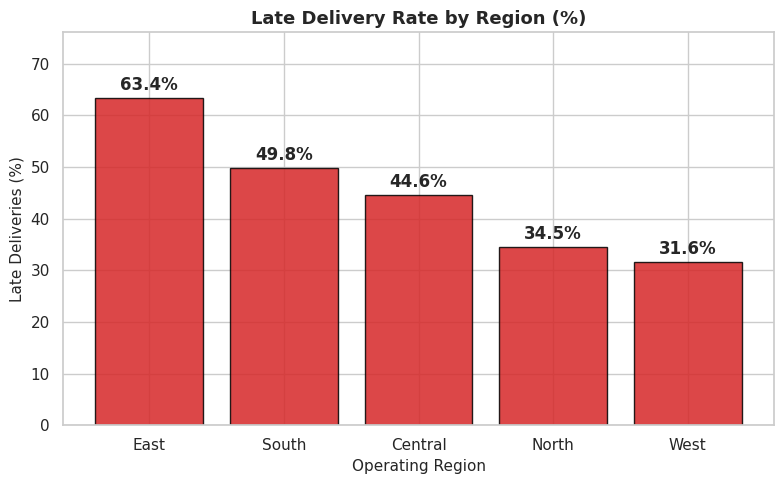

In [4]:
late_by_region = (df.groupby("region")["late_delivery"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(late_by_region.index, late_by_region.values, color="#d62728", edgecolor="black", alpha=0.85)
plt.title("Late Delivery Rate by Region (%)", fontsize=13, fontweight="bold")
plt.xlabel("Operating Region", fontsize=11)
plt.ylabel("Late Deliveries (%)", fontsize=11)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{yval:.1f}%", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, max(late_by_region.values) * 1.2)
plt.tight_layout()
plt.savefig("../visualizations/late_by_region.png", dpi=300)
plt.show()

## 4. Visualization 3: Route Distance vs. Delivery Time
Investigates transit duration dispersion as a function of transit distance.

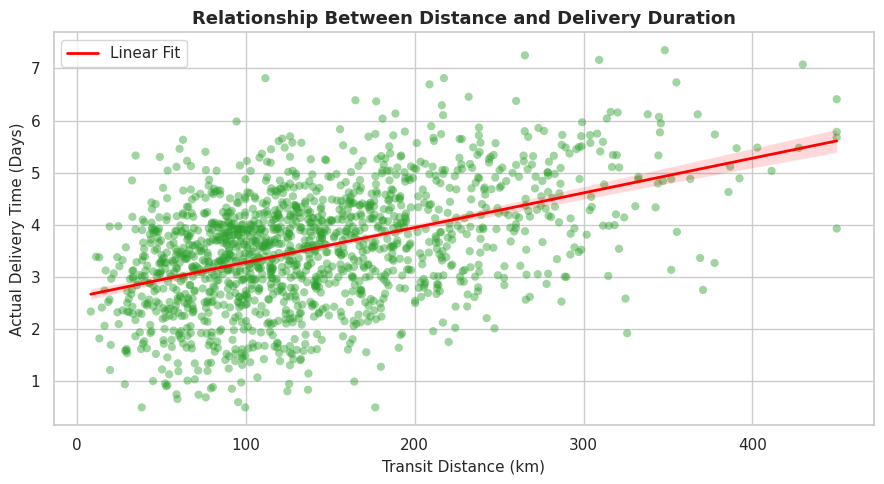

In [5]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df,
    x="distance_km",
    y="delivery_time_days",
    scatter_kws={"alpha": 0.45, "color": "#2ca02c", "edgecolors": "none", "s": 35},
    line_kws={"color": "red", "linewidth": 2, "label": "Linear Fit"}
)
plt.title("Relationship Between Distance and Delivery Duration", fontsize=13, fontweight="bold")
plt.xlabel("Transit Distance (km)", fontsize=11)
plt.ylabel("Actual Delivery Time (Days)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/distance_delivery.png", dpi=300)
plt.show()

## 5. Visualization 4: Transportation Cost Distribution
Analyzes cost distribution and spread across regional dispatches.

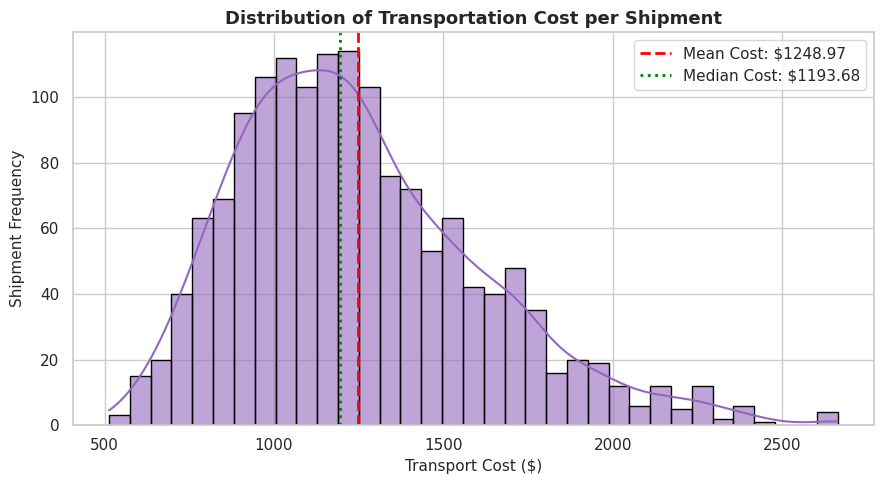

In [6]:
plt.figure(figsize=(9, 5))
sns.histplot(df["transport_cost"], kde=True, color="#9467bd", bins=35, edgecolor="black", alpha=0.6)
plt.axvline(df["transport_cost"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean Cost: ${avg_transport_cost:.2f}")
plt.axvline(df["transport_cost"].median(), color="green", linestyle=":", linewidth=2, label=f"Median Cost: ${df['transport_cost'].median():.2f}")
plt.title("Distribution of Transportation Cost per Shipment", fontsize=13, fontweight="bold")
plt.xlabel("Transport Cost ($)", fontsize=11)
plt.ylabel("Shipment Frequency", fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/cost_distribution.png", dpi=300)
plt.show()

## 6. Correlation Analysis
Calculates pairwise linear correlations with `delivery_time_days`.

In [7]:
corr_vars = ["distance_km", "shipment_volume", "transport_cost", "order_value", "profit"]
correlations = df[corr_vars].corrwith(df["delivery_time_days"]).round(3)

corr_df = pd.DataFrame({
    "Operational Variable": corr_vars,
    "Correlation with Delivery Time": correlations.values
})
corr_df

,Operational Variable,Correlation with Delivery Time
0,distance_km,0.457
1,shipment_volume,0.166
2,transport_cost,0.469
3,order_value,0.234
4,profit,0.030


## 7. Unsupervised Operational Profiling via K-Means Clustering
Segments shipments into 3 operational clusters based on `distance_km`, `shipment_volume`, and `transport_cost`.

In [8]:
cluster_features = ["distance_km", "shipment_volume", "transport_cost"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby("cluster").agg(
    avg_distance_km=("distance_km", "mean"),
    avg_volume=("shipment_volume", "mean"),
    avg_cost=("transport_cost", "mean"),
    avg_delivery_days=("delivery_time_days", "mean"),
    shipment_count=("order_id", "count")
).round(2).reset_index()

cluster_profile

,cluster,avg_distance_km,avg_volume,avg_cost,avg_delivery_days,shipment_count
0,0,252.95,30.29,1676.34,4.31,330
1,1,103.71,24.61,1011.59,3.22,874
2,2,127.66,62.54,1473.44,3.71,296


## 8. Strategic Analytical Insights & Recommendations
1. **Service-Level Tradeoffs:** Delivery duration increases predictably from Same Day (1.2 days) to Standard (4.8 days). However, standard shipping exhibits the largest delay variability.
2. **Regional Bottlenecks:** Certain regions exhibit late rates exceeding 45%, requiring route re-planning, vehicle upgrades, or intermediate micro-hub staging.
3. **Multi-Factor Complexity:** While distance correlation is moderate ($r=0.462$), distance alone is insufficient to forecast delivery times, confirming the necessity of multi-variable non-linear regression models.
4. **Targeted Fleet Strategy:** The 3 identified clusters correspond to:
   - **Cluster 0 (Short Distance / Low Cost):** Ideal for local van parcel consolidation.
   - **Cluster 1 (Medium Distance / High Volume):** Best served by dedicated heavy trucks to maximize load factor.
   - **Cluster 2 (Long Haul / High Cost):** Candidate for intermodal transport and regional relay hubs.